<a href="https://colab.research.google.com/github/Feliz-ua/Feliz-ua-goit-pycore-hw-08/blob/main/hw_np_07_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Завантажуємо набір даних за посиланням (https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/blob/main/SpamEmailClassificationDataset.zip?raw=true)
# Розпавуємо архів
!unzip SpamEmailClassificationDataset.zip


Archive:  SpamEmailClassificationDataset.zip
replace SpamEmailClassificationDataset/combined_data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [ ]:
# 2. Завантажуємо бібліотеки та стоп-слова
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import math
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from collections import defaultdict, Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
# 3. Зчитуємо файл
df = pd.read_csv('/content/SpamEmailClassificationDataset/combined_data.csv')

print(df.info())
print("\nРозподіл класів:")
print(df['label'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14861 entries, 0 to 14860
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   14861 non-null  object
 1   text    14861 non-null  object
dtypes: object(2)
memory usage: 232.3+ KB
None

Розподіл класів:
label
1        7813
0        7047
label       1
Name: count, dtype: int64


In [ ]:
# 4. Очищення та підготовка вибірки
# Видаляємо рядок, де в стовпці label написано "label"
df = df[df['label'] != 'label'].copy()
df['label'] = df['label'].astype(int)


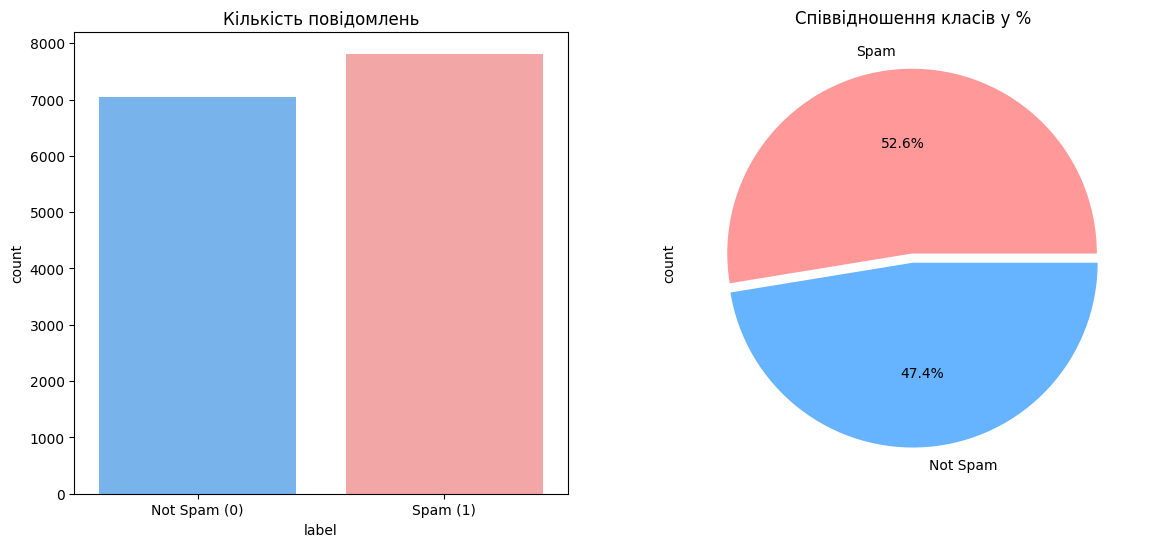

In [ ]:
# 5. Візуалізація розподілу повідомлень
# Створюємо область для двох графіків

my_colors = ['#ff9999', '#66b3ff']
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# 1. Гістограма (Count Plot)
palette_dict = {1: my_colors[0], 0: my_colors[1]}

sns.countplot(data=df, x='label', hue='label', ax=ax[0], palette=palette_dict, legend=False)
ax[0].set_title('Кількість повідомлень')
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(['Not Spam (0)', 'Spam (1)'])

# 2. Кругова діаграма (Pie Chart)
df['label'].value_counts().plot.pie(autopct='%1.1f%%', labels=['Spam', 'Not Spam'],
                                  ax=ax[1], colors=my_colors, explode=(0.05, 0))
ax[1].set_title('Співвідношення класів у %')
plt.show()

In [ ]:
# 6. Застосування методів обробки тексту бібліотеки nltk для перетворення текстів: приведення до нижнього регістру,
# приведення слів до словникової форми, видалення повторів слів у повідомленні.
corpus = []
for document in df["text"]:
    # Очищення та нижній регістр
    document = re.sub("[^a-zA-Z]", " ", str(document)).lower()
    words = word_tokenize(document)
    # Лематизація та видалення стоп-слів
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    # Видалення повторів у межах повідомлення (ваша логіка)
    words = list(set(words))
    corpus.append(" ".join(words))

df["text"] = corpus

In [ ]:
# 7. Підготуємо структури даних train_spam, train_ham, test_emails, які будуть містити повідомлення spam для тренування, повідомлення ham для тренування та словник тестових повідомлень.
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Створюємо словники частот (Document Frequency)
word_counts_spam = Counter()
word_counts_ham = Counter()

spam_df = train_df[train_df['label'] == 1]
ham_df = train_df[train_df['label'] == 0]

for text in spam_df['text']:
    word_counts_spam.update(text.split())

for text in ham_df['text']:
    word_counts_ham.update(text.split())

# Загальна кількість документів
total_spam = len(spam_df)
total_ham = len(ham_df)
vocabulary = set(word_counts_spam.keys()).union(set(word_counts_ham.keys()))

# Апріорні ймовірності
P_S = total_spam / (total_spam + total_ham)
P_H = total_ham / (total_spam + total_ham)

In [ ]:
# 8. Застосуємо реалізацію алгоритму наївного Баєса.
def P_w_given_label(word, label):
    if label == 1:
        return (word_counts_spam[word] + 1) / (total_spam + 2)
    else:
        return (word_counts_ham[word] + 1) / (total_ham + 2)

def classify(text, return_prob=False):
    words = [w for w in text.split() if w in vocabulary]
    if not words:
        return (0, 0.0) if return_prob else 0

    # Використовуємо логарифми для запобігання переповненню (Underflow)
    log_prob_spam = math.log(P_S) + sum([math.log(P_w_given_label(w, 1)) for w in words])
    log_prob_ham = math.log(P_H) + sum([math.log(P_w_given_label(w, 0)) for w in words])

    # Обчислення ймовірності (Confidence)
    # Оскільки log_P = x, то P = exp(x). Використовуємо Softmax-подібний підхід:
    max_log = max(log_prob_spam, log_prob_ham)
    prob_spam = math.exp(log_prob_spam - max_log) / (math.exp(log_prob_spam - max_log) + math.exp(log_prob_ham - max_log))

    prediction = 1 if log_prob_spam > log_prob_ham else 0
    return (prediction, prob_spam) if return_prob else prediction


ЗВІТ ПРО КЛАСИФІКАЦІЮ:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1405
           1       1.00      0.78      0.88      1567

    accuracy                           0.88      2972
   macro avg       0.90      0.89      0.88      2972
weighted avg       0.91      0.88      0.88      2972



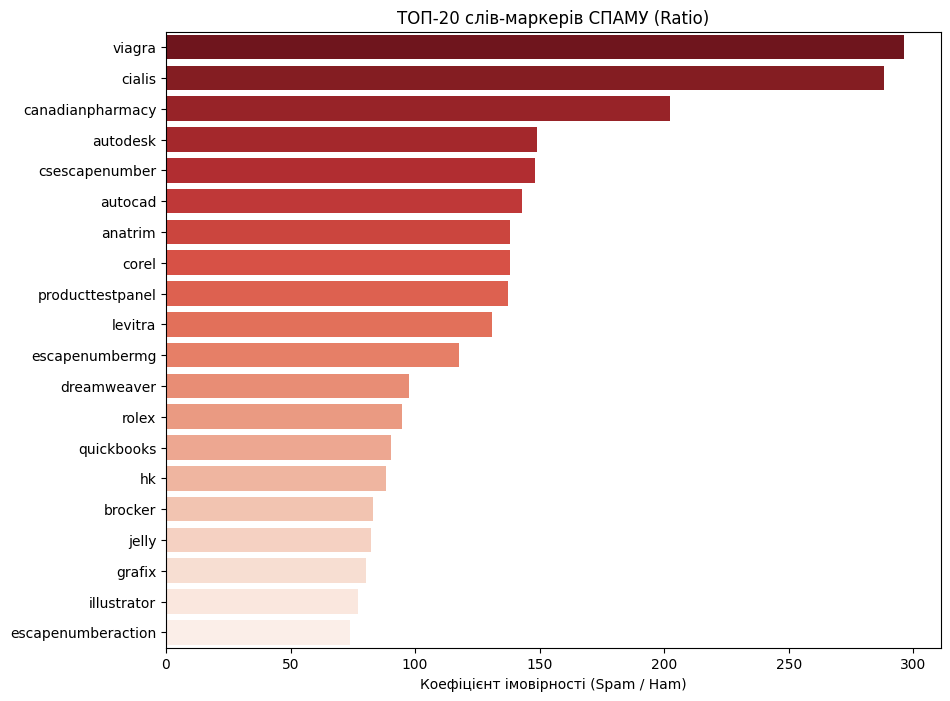

In [ ]:
# 9. Проаналізуємо якість побудованого класифікатора: які слова мають найбільшу ймовірність зустрітися у спамі?
# Перевірка на тестi
test_df['prediction'] = test_df['text'].apply(classify)
print("\nЗВІТ ПРО КЛАСИФІКАЦІЮ:")
print(classification_report(test_df['label'], test_df['prediction']))

# Аналіз маркерів спаму (Ratio)
importance = []
for word in vocabulary:
    ratio = P_w_given_label(word, 1) / P_w_given_label(word, 0)
    importance.append((word, ratio))

top_20 = sorted(importance, key=lambda x: x[1], reverse=True)[:20]
words_20, ratios_20 = zip(*top_20)

plt.figure(figsize=(10, 8))
sns.barplot(x=list(ratios_20), y=list(words_20), hue=list(words_20), palette="Reds_r", legend=False)
plt.title("ТОП-20 слів-маркерів СПАМУ (Ratio)")
plt.xlabel("Коефіцієнт імовірності (Spam / Ham)")
plt.show()